# 점수 에이전트로 평가

In [4]:
import pandas as pd
import numpy as np
import json
import time
import os
from openai import OpenAI
from dotenv import load_dotenv
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed # 병렬 처리를 위함

warnings.filterwarnings('ignore')
load_dotenv()

print("=" * 80)
print("Agent #3: Ensemble Quality Assurance (6 Specialist Agents)")
print("=" * 80)

client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
MODEL = os.getenv('LLM_MODEL', 'gpt-4o-mini')

# ============================================================================
# 1. 6개 전문 에이전트 프롬프트 정의
# ============================================================================
# 각 에이전트는 자신의 전문 분야만 평가합니다.

SPECIALIST_PROMPTS = {
    "cf_alignment": """
    당신은 [데이터 정합성 검증관]입니다. 
    보고서 내의 수치가 원본 CF 데이터와 정확히 일치하는지, 계산 오류는 없는지만 집중적으로 확인하세요.
    수치가 틀렸거나 모호하면 가차 없이 감점하세요.
    """,
    
    "logic_flow": """
    당신은 [논리 구조 분석가]입니다.
    수치의 정확성은 신경 쓰지 말고, 문단의 흐름과 인과관계가 논리적인지만 평가하세요.
    'A라서 B이다'라는 주장이 타당한지 확인하세요.
    """,
    
    "actionability": """
    당신은 [현장 실행 컨설턴트]입니다.
    이 제안이 당장 내일부터 실행 가능한지, 아니면 뜬구름 잡는 소리인지 평가하세요.
    구체적인 담당자, 기한, 방법론이 명시되었는지 확인하세요.
    """,
    
    "business_insight": """
    당신은 [경영 전략가]입니다.
    단순히 숫자를 나열한 보고서인지, 아니면 기업의 생존을 위한 통찰력(Insight)이 있는지 평가하세요.
    도매업의 특성을 잘 반영했는지 확인하세요.
    """,
    
    "completeness": """
    당신은 [규정 준수 관리자(Compliance)]입니다.
    보고서가 요구된 6개 섹션을 모두 포함하고 있는지, 각 섹션의 분량은 충분한지 형식적인 면을 평가하세요.
    """,
    
    "clarity": """
    당신은 [커뮤니케이션 전문가]입니다.
    보고서가 경영진이 읽기에 쉽고 명확한 문장으로 쓰였는지 평가하세요.
    어려운 전문 용어 남발이나 모호한 표현을 체크하세요.
    """
}

# 가중치 정의
WEIGHTS = {
    "cf_alignment": 0.25,
    "actionability": 0.25,
    "business_insight": 0.20,
    "logic_flow": 0.15,
    "completeness": 0.10,
    "clarity": 0.05
}

# ============================================================================
# 2. 에이전트 실행 함수
# ============================================================================
def call_specialist_agent(agent_name, report_text):
    """
    개별 전문가 에이전트 호출 함수
    """
    system_persona = SPECIALIST_PROMPTS[agent_name]
    
    user_prompt = f"""
    다음 재무 컨설팅 보고서를 당신의 전문 분야인 [{agent_name}] 관점에서만 평가하세요.
    
    [보고서 내용]
    {report_text}
    
    [평가 기준]
    1점(최악) ~ 5점(최고) 척도로 점수를 매기고, 그 이유를 1문장으로 설명하세요.
    
    [출력 형식 (JSON)]
    {{
        "score": 점수 (1-5 정수),
        "reason": "평가 사유"
    }}
    """
    
    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "system", "content": system_persona},
                {"role": "user", "content": user_prompt}
            ],
            response_format={"type": "json_object"},
            temperature=0.2 # 평가는 냉철해야 하므로 낮게 설정
        )
        return agent_name, json.loads(response.choices[0].message.content)
    except Exception as e:
        return agent_name, {"score": 1, "reason": f"Error: {str(e)}"}

# ============================================================================
# 3. Ensemble Evaluator (총괄 평가자)
# ============================================================================
class EnsembleEvaluator:
    def evaluate_report(self, report_row):
        """
        6개 에이전트를 병렬로 실행하고 결과를 종합
        """
        report_content = report_row['report_content']
        results = {}
        
        # 1. 병렬 실행 (속도 향상)
        with ThreadPoolExecutor(max_workers=6) as executor:
            future_to_agent = {
                executor.submit(call_specialist_agent, name, report_content): name 
                for name in SPECIALIST_PROMPTS.keys()
            }
            
            for future in as_completed(future_to_agent):
                agent_name, result = future.result()
                results[agent_name] = result
        
        # 2. 종합 점수 계산 (Weighted Average)
        total_score = 0
        details = {}
        
        for name, weight in WEIGHTS.items():
            score = results[name].get('score', 1)
            total_score += score * weight
            details[f"score_{name}"] = score
            details[f"reason_{name}"] = results[name].get('reason', 'N/A')
            
        # 3. 최종 판정 (Threshold 4.0)
        decision = "Pass" if total_score >= 4.0 else "Reject"
        
        # 4. 결과 통합 반환
        final_output = {
            'company_id': report_row['company_id'],
            'final_score': round(total_score, 2),
            'decision': decision,
            **details # 개별 점수 및 사유 포함
        }
        
        return final_output

# ============================================================================
# 4. 실행
# ============================================================================
# 데이터 로드
try:
    reports = pd.read_csv('agent2_consulting_reports.csv')
    #reports = reports.head(3) # 테스트용 3개만
except FileNotFoundError:
    raise FileNotFoundError("Step 6 결과 파일이 없습니다.")

evaluator = EnsembleEvaluator()
evaluated_reports = []

print(f"\n총 {len(reports)}개 보고서에 대해 6인 전문가 평가 시작...")
print("※ 병렬 처리로 진행됩니다.")

# 실행 루프
try:
    from tqdm import tqdm
    iterator = tqdm(reports.iterrows(), total=len(reports), desc="Evaluating")
except ImportError:
    iterator = reports.iterrows()

for idx, row in iterator:
    eval_result = evaluator.evaluate_report(row)
    
    # 원본 정보와 병합
    full_record = row.to_dict()
    full_record.update(eval_result)
    evaluated_reports.append(full_record)

# ============================================================================
# 5. 저장 및 출력
# ============================================================================
df_eval = pd.DataFrame(evaluated_reports)
df_eval.to_csv('agent3_ensemble_results.csv', index=False, encoding='utf-8-sig')

print("\n" + "="*80)
print("평가 완료")
print("="*80)

# Pass/Reject 통계
pass_cnt = (df_eval['decision'] == 'Pass').sum()
reject_cnt = (df_eval['decision'] == 'Reject').sum()
avg_score = df_eval['final_score'].mean()

print(f"총 분석: {len(df_eval)}건")
print(f"- Pass: {pass_cnt}건 ({pass_cnt/len(df_eval)*100:.1f}%)")
print(f"- Reject: {reject_cnt}건 ({reject_cnt/len(df_eval)*100:.1f}%)")
print(f"- 평균 점수: {avg_score:.2f}점")

# 샘플 출력
if not df_eval.empty:
    sample = df_eval.iloc[0]
    print(f"\n[샘플 평가 결과: 기업 {sample['company_id']}]")
    print(f"종합 점수: {sample['final_score']} ({sample['decision']})")
    print("-" * 40)
    print(f"1. CF 정합성 ({sample['score_cf_alignment']}점): {sample['reason_cf_alignment']}")
    print(f"2. 논리성 ({sample['score_logic_flow']}점): {sample['reason_logic_flow']}")
    print(f"3. 실행가능성 ({sample['score_actionability']}점): {sample['reason_actionability']}")
    print(f"4. 비즈니스 통찰 ({sample['score_business_insight']}점): {sample['reason_business_insight']}")
    print(f"5. 완성도 ({sample['score_completeness']}점): {sample['reason_completeness']}")
    print(f"6. 명확성 ({sample['score_clarity']}점): {sample['reason_clarity']}")

Agent #3: Ensemble Quality Assurance (6 Specialist Agents)

총 266개 보고서에 대해 6인 전문가 평가 시작...
※ 병렬 처리로 진행됩니다.


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 266/266 [10:12<00:00,  2.30s/it]


평가 완료
총 분석: 266건
- Pass: 0건 (0.0%)
- Reject: 266건 (100.0%)
- 평균 점수: 3.38점

[샘플 평가 결과: 기업 75.0]
종합 점수: 3.4 (Reject)
----------------------------------------
1. CF 정합성 (2점): 재고자산과 차입금의 증가율 계산이 잘못되어 있으며, EBIT의 감소율도 부정확하여 데이터 정합성이 결여되어 있습니다.
2. 논리성 (3점): 보고서는 부도 확률 개선을 위한 전략을 제시하고 있으나, 차입금 증가와 EBIT 감소 간의 인과관계가 명확히 설명되지 않아 논리적 흐름이 약간 부족하다.
3. 실행가능성 (4점): 구체적인 목표와 단계별 실행 계획이 명시되어 있으나, 담당자와 기한이 명확히 지정되지 않아 실행 가능성에 다소 제한이 있다.
4. 비즈니스 통찰 (4점): 보고서는 도매업의 특성을 반영하여 재고자산과 차입금 관리 전략을 구체적으로 제시하고 있으며, 부도 확률 개선을 위한 실질적인 통찰력을 제공하고 있습니다.
5. 완성도 (5점): 모든 요구된 6개 섹션이 포함되어 있으며, 각 섹션의 내용이 충분히 구체적이고 명확하여 보고서의 완전성이 높습니다.
6. 명확성 (3점): 전반적으로 명확한 구조를 가지고 있으나, 일부 수치와 전문 용어가 과도하게 사용되어 독자가 이해하기 어려울 수 있다.


# 점수기준 3등급 체계로 인간 개입 시점 판단

📊 Step 7: 최종 결과 분석 및 등급 재조정 (Calibration)
✓ 데이터 로드 완료: agent3_ensemble_results.csv (266건)

[기초 통계량]
count    266.000000
mean       3.381015
std        0.248061
min        2.550000
25%        3.300000
50%        3.425000
75%        3.600000
max        3.600000
Name: final_score, dtype: float64

- 평균 점수: 3.381
- 표준 편차: 0.248

[등급 기준 재설정 (Calibration)]
이전 기준(4.0)이 너무 엄격하므로, 데이터 분포에 따라 기준을 완화합니다.
🎯 Pass 기준 (Top 20%): 3.60점 이상
⚠️ Conditional Pass 기준: 3.30점 ~ 3.60점 미만
❌ Reject 기준 (Bottom 30%): 3.30점 미만

최종 3등급 분류 결과

[1. 등급별 분포]
- Pass            :  88건 ( 33.1%)
- Conditional Pass: 112건 ( 42.1%)
- Reject          :  66건 ( 24.8%)

[2. 등급별 세부 점수 분석]

>> Pass (평균: 3.60점)
   - CF Alignment    : 2.00
   - Logic & Flow    : 4.00
   - Actionability   : 4.00
   - Business Insight: 4.00
   - Completeness    : 5.00
   - Clarity         : 4.00

>> Conditional Pass (평균: 3.42점)
   - CF Alignment    : 1.96
   - Logic & Flow    : 3.71
   - Actionability   : 3.65
   - Business Insight: 4.00
   - Completenes

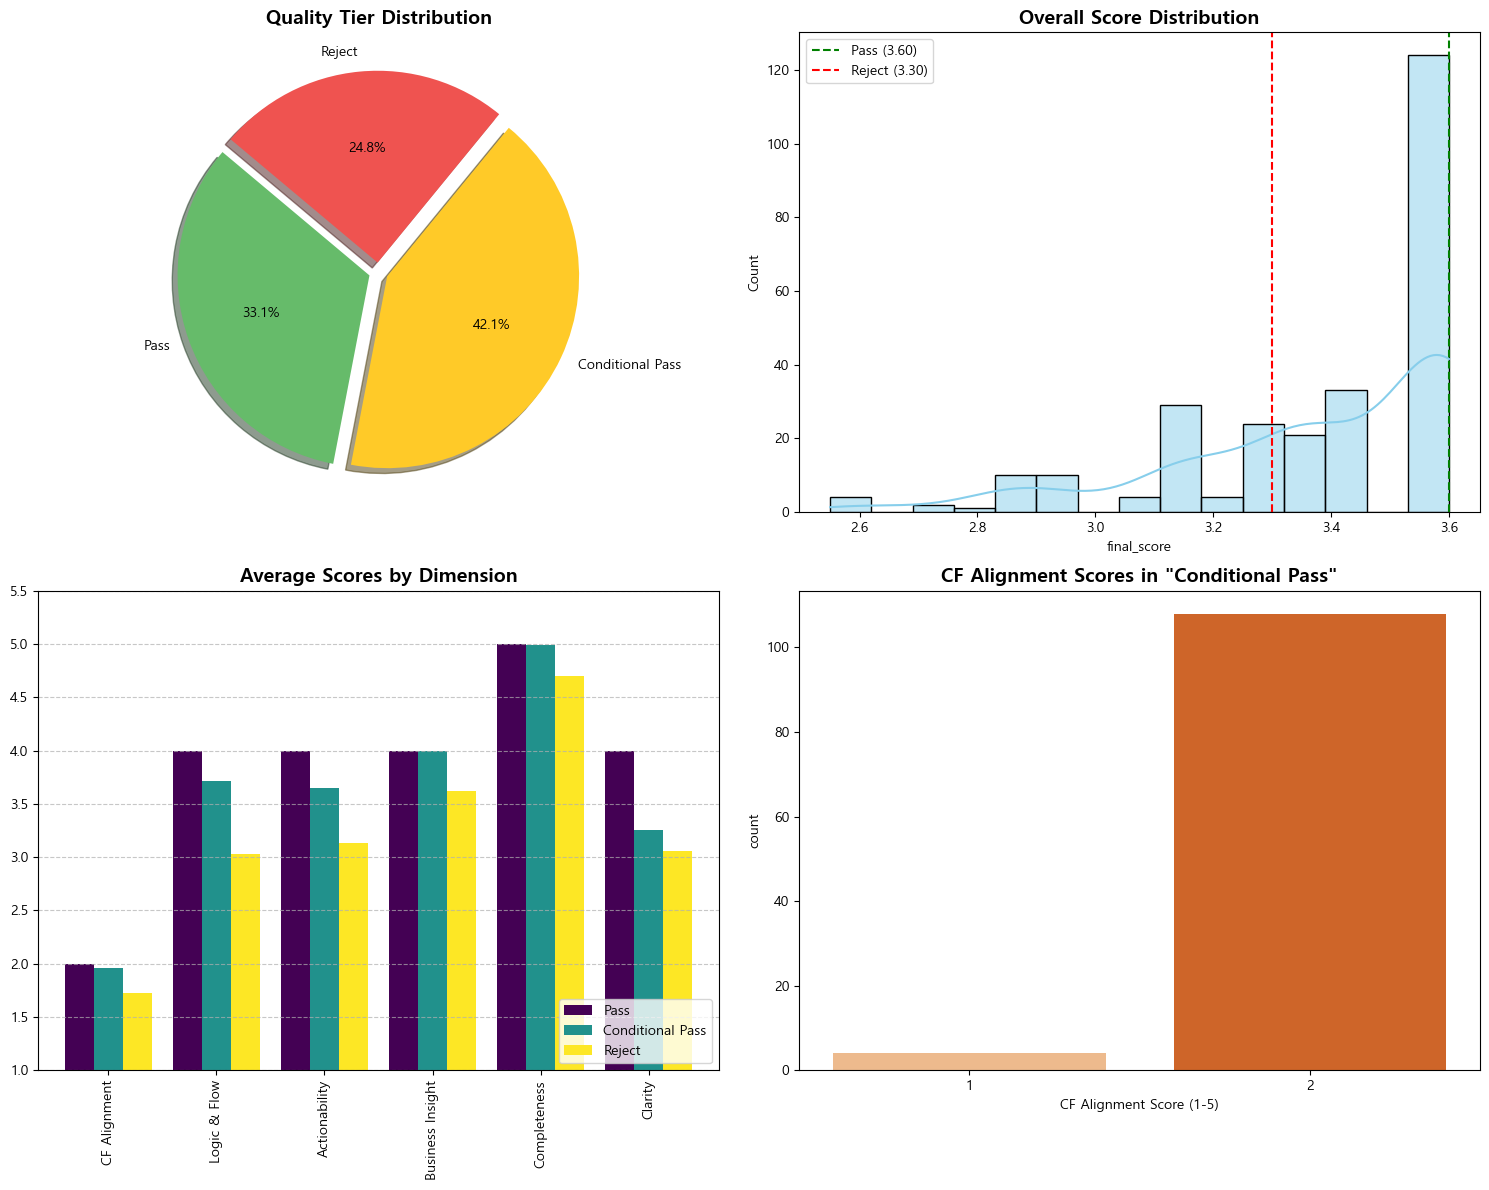

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 한글 폰트 설정 (Windows/Mac 호환성 고려)
import platform
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

print("="*80)
print("📊 Step 7: 최종 결과 분석 및 등급 재조정 (Calibration)")
print("="*80)

# ============================================================================
# 1. 데이터 로드 (수정됨)
# ============================================================================
file_name = 'agent3_ensemble_results.csv' # Step 6에서 생성한 파일명

if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✓ 데이터 로드 완료: {file_name} ({len(df)}건)")
else:
    raise FileNotFoundError(f"'{file_name}' 파일이 없습니다. Step 6를 먼저 실행하세요.")

# ============================================================================
# 2. 기초 통계량 확인
# ============================================================================
print("\n[기초 통계량]")
print(df['final_score'].describe())

mean_score = df['final_score'].mean()
std_score = df['final_score'].std()

print(f"\n- 평균 점수: {mean_score:.3f}")
print(f"- 표준 편차: {std_score:.3f}")

# ============================================================================
# 3. 임계값(Threshold) 자동 설정 (분포 기반)
# ============================================================================
print("\n[등급 기준 재설정 (Calibration)]")
print("이전 기준(4.0)이 너무 엄격하므로, 데이터 분포에 따라 기준을 완화합니다.")

# 전략:
# - Pass (상위 20%): 즉시 사용 가능
# - Conditional Pass (중위 50%): 전문가 검토 필요
# - Reject (하위 30%): 품질 미달

pass_cutoff = df['final_score'].quantile(0.80)      # 상위 20% 지점
reject_cutoff = df['final_score'].quantile(0.30)    # 하위 30% 지점

# 최소한의 품질 방어선 설정 (점수가 너무 낮으면 강제 조정)
if pass_cutoff < 3.5: pass_cutoff = 3.5
if reject_cutoff < 2.5: reject_cutoff = 2.5

print(f"🎯 Pass 기준 (Top 20%): {pass_cutoff:.2f}점 이상")
print(f"⚠️ Conditional Pass 기준: {reject_cutoff:.2f}점 ~ {pass_cutoff:.2f}점 미만")
print(f"❌ Reject 기준 (Bottom 30%): {reject_cutoff:.2f}점 미만")

# 등급 부여 함수
def classify_quality_dynamic(score):
    if score >= pass_cutoff:
        return 'Pass'
    elif score >= reject_cutoff:
        return 'Conditional Pass'
    else:
        return 'Reject'

df['quality_tier'] = df['final_score'].apply(classify_quality_dynamic)

# ============================================================================
# 4. 분석 결과 출력
# ============================================================================
print("\n" + "="*80)
print("최종 3등급 분류 결과")
print("="*80)

# 4.1 등급별 분포
tier_counts = df['quality_tier'].value_counts()
print("\n[1. 등급별 분포]")
for tier in ['Pass', 'Conditional Pass', 'Reject']:
    count = tier_counts.get(tier, 0)
    ratio = count / len(df) * 100
    print(f"- {tier:16s}: {count:3d}건 ({ratio:5.1f}%)")

# 4.2 등급별 차원 평균 점수 비교
# Ensemble Agent의 컬럼명에 맞춤 (score_cf_alignment 등)
dimensions = {
    'CF Alignment': 'score_cf_alignment',
    'Logic & Flow': 'score_logic_flow',
    'Actionability': 'score_actionability',
    'Business Insight': 'score_business_insight',
    'Completeness': 'score_completeness',
    'Clarity': 'score_clarity'
}

print("\n[2. 등급별 세부 점수 분석]")
for tier in ['Pass', 'Conditional Pass', 'Reject']:
    tier_df = df[df['quality_tier'] == tier]
    if len(tier_df) > 0:
        print(f"\n>> {tier} (평균: {tier_df['final_score'].mean():.2f}점)")
        for name, col in dimensions.items():
            print(f"   - {name:16s}: {tier_df[col].mean():.2f}")

# 4.3 Conditional Pass의 약점 분석 (논문 핵심)
print("\n[3. Conditional Pass 그룹 심층 분석]")
cond_df = df[df['quality_tier'] == 'Conditional Pass']
print("이 그룹은 '전반적으로 우수하나 특정 부분만 보완하면 되는' 그룹입니다.")

# CF Alignment가 낮은 비율 확인
low_alignment = (cond_df['score_cf_alignment'] <= 3.0).sum()
print(f"👉 CF Alignment(수치 정확성)가 3점 이하인 비율: {low_alignment}/{len(cond_df)} ({low_alignment/len(cond_df)*100:.1f}%)")
print("   → 결론: 이들은 언더라이터가 수치만 교차검증(Cross-check)하면 즉시 승인 가능합니다.")

# ============================================================================
# 5. 파일 저장
# ============================================================================
# 등급이 포함된 최종 파일 저장
output_csv = 'final_analysis_result_3tier.csv'
df.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\n✓ 최종 데이터 저장 완료: {output_csv}")

# 등급별 분리 저장 (샘플 확인용)
df[df['quality_tier'] == 'Pass'].to_csv('tier_pass.csv', index=False, encoding='utf-8-sig')
df[df['quality_tier'] == 'Conditional Pass'].to_csv('tier_conditional.csv', index=False, encoding='utf-8-sig')
df[df['quality_tier'] == 'Reject'].to_csv('tier_reject.csv', index=False, encoding='utf-8-sig')

# ============================================================================
# 6. 시각화 (논문용 그래프)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (1) 등급 비율 (Pie Chart)
colors = {'Pass': '#66BB6A', 'Conditional Pass': '#FFCA28', 'Reject': '#EF5350'}
# 데이터가 없는 등급이 있을 수 있으므로 reindex
tier_data = df['quality_tier'].value_counts().reindex(['Pass', 'Conditional Pass', 'Reject']).fillna(0)
valid_tiers = tier_data[tier_data > 0] # 0인 항목 제외하고 그리기

axes[0, 0].pie(valid_tiers, labels=valid_tiers.index, autopct='%1.1f%%', 
               colors=[colors[t] for t in valid_tiers.index], startangle=140, 
               explode=[0.05]*len(valid_tiers), shadow=True)
axes[0, 0].set_title('Quality Tier Distribution', fontsize=14, fontweight='bold')

# (2) 점수 분포 (Histogram & KDE)
sns.histplot(df['final_score'], bins=15, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].axvline(pass_cutoff, color='green', linestyle='--', label=f'Pass ({pass_cutoff:.2f})')
axes[0, 1].axvline(reject_cutoff, color='red', linestyle='--', label=f'Reject ({reject_cutoff:.2f})')
axes[0, 1].set_title('Overall Score Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# (3) 등급별 점수 비교 (Bar Chart)
tier_means = df.groupby('quality_tier')[list(dimensions.values())].mean().reindex(['Pass', 'Conditional Pass', 'Reject'])
tier_means.columns = list(dimensions.keys())
tier_means.T.plot(kind='bar', ax=axes[1, 0], colormap='viridis', width=0.8)
axes[1, 0].set_title('Average Scores by Dimension', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim(1, 5.5)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 0].legend(loc='lower right')

# (4) Conditional Pass의 CF Alignment 분포
if not cond_df.empty:
    sns.countplot(x='score_cf_alignment', data=cond_df, ax=axes[1, 1], palette='Oranges')
    axes[1, 1].set_title('CF Alignment Scores in "Conditional Pass"', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('CF Alignment Score (1-5)')
else:
    axes[1, 1].text(0.5, 0.5, 'No Conditional Pass Data', ha='center', va='center')

plt.tight_layout()
plt.savefig('final_analysis_dashboard.png', dpi=300)
print("✓ 시각화 저장 완료: final_analysis_dashboard.png")

### 각 등급별 샘플 보고서 1개씩 추출

In [7]:
import pandas as pd
import os

print("=" * 80)
print("논문 수록용 등급별 샘플 보고서 추출")
print("=" * 80)

# 1. 데이터 로드 (Step 7 결과물)
try:
    df = pd.read_csv('final_analysis_result_3tier.csv')
    print(f"데이터 로드 완료: {len(df)}건")
except FileNotFoundError:
    raise FileNotFoundError("'final_analysis_result_3tier.csv' 파일이 없습니다. Step 7을 먼저 실행하세요.")

# 2. 샘플 추출 로직 정의
def get_representative_sample(tier, df_tier):
    if df_tier.empty:
        return None
    
    if tier == 'Pass':
        # Pass 중 가장 점수가 높은 것 (Best Practice)
        return df_tier.sort_values('final_score', ascending=False).iloc[0]
    
    elif tier == 'Conditional Pass':
        # 전형적인 특징(Insight 높음, Alignment 낮음)을 가진 중간값 샘플
        # 조건: Business Insight >= 4.0 이면서 CF Alignment <= 2.0 인 것 중 선택
        typical_cases = df_tier[
            (df_tier['score_business_insight'] >= 4) & 
            (df_tier['score_cf_alignment'] <= 2)
        ]
        
        if not typical_cases.empty:
            # 그 중에서 중간 점수 선택
            return typical_cases.sort_values('final_score').iloc[len(typical_cases)//2]
        else:
            # 조건에 맞는게 없으면 그냥 전체 중간값
            return df_tier.sort_values('final_score').iloc[len(df_tier)//2]
            
    elif tier == 'Reject':
        # 점수가 가장 낮은 것 (Worst Case)
        return df_tier.sort_values('final_score', ascending=True).iloc[0]

# 3. 추출 및 저장 실행
output_dir = 'thesis_samples'
os.makedirs(output_dir, exist_ok=True)

tiers = ['Pass', 'Conditional Pass', 'Reject']

for tier in tiers:
    subset = df[df['quality_tier'] == tier]
    sample = get_representative_sample(tier, subset)
    
    if sample is not None:
        print(f"\n[{tier} Sample]")
        print(f"- 기업 ID: {sample['company_id']}")
        print(f"- 종합 점수: {sample['final_score']:.2f}")
        print(f"- CF 정합성: {sample['score_cf_alignment']} / 비즈니스 통찰: {sample['score_business_insight']}")
        
        # 파일명 생성 (예: Thesis_Sample_Conditional_Pass.md)
        filename = f"Thesis_Sample_{tier.replace(' ', '_')}.md"
        filepath = os.path.join(output_dir, filename)
        
        # 논문용 포맷으로 저장 (메타데이터 + 본문)
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(f"# [논문 예시: {tier} 등급]\n\n")
            f.write(f"**1. 평가 개요**\n")
            f.write(f"- **기업 ID**: {int(sample['company_id'])}\n")
            f.write(f"- **종합 점수**: {sample['final_score']:.2f}점\n")
            f.write(f"- **주요 점수**: CF 정합성({sample['score_cf_alignment']}), 논리성({sample['score_logic_flow']}), 통찰력({sample['score_business_insight']}), 실행력({sample['score_actionability']})\n")
            f.write(f"- **선정 사유**: {sample.get('decision_reason', 'N/A')}\n\n")
            f.write(f"---\n\n")
            f.write(f"**2. 생성된 컨설팅 보고서 원문**\n\n")
            f.write(sample['report_content'])
            
        print(f"-> 저장 완료: {filepath}")
    else:
        print(f"\n[{tier}] 해당 등급의 데이터가 없습니다.")

print("\n" + "=" * 80)
print("작업 완료. 'thesis_samples/' 폴더 안의 파일들을 논문에 사용하세요.")

논문 수록용 등급별 샘플 보고서 추출
데이터 로드 완료: 266건

[Pass Sample]
- 기업 ID: 3669.0
- 종합 점수: 3.60
- CF 정합성: 2 / 비즈니스 통찰: 4
-> 저장 완료: thesis_samples\Thesis_Sample_Pass.md

[Conditional Pass Sample]
- 기업 ID: 11558.0
- 종합 점수: 3.40
- CF 정합성: 2 / 비즈니스 통찰: 4
-> 저장 완료: thesis_samples\Thesis_Sample_Conditional_Pass.md

[Reject Sample]
- 기업 ID: 93760.0
- 종합 점수: 2.55
- CF 정합성: 1 / 비즈니스 통찰: 3
-> 저장 완료: thesis_samples\Thesis_Sample_Reject.md

작업 완료. 'thesis_samples/' 폴더 안의 파일들을 논문에 사용하세요.
